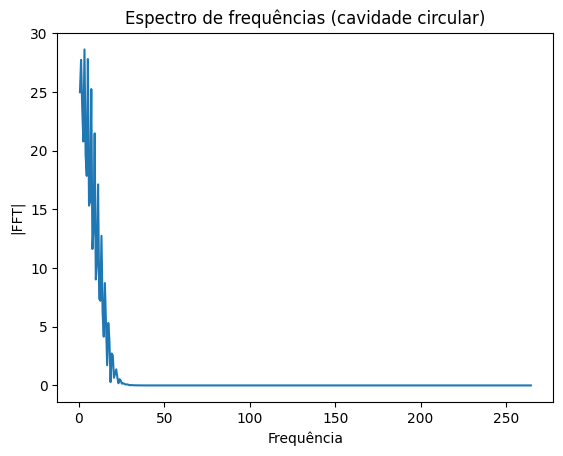

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- parâmetros físicos ---
eps = 1.0
mu = 1.0
c = 1 / np.sqrt(eps * mu)

# --- domínio ---
a = 0.5
Nx = Ny = 150
dx = dy = 2*a / Nx

dt = 0.4 / (c * np.sqrt(1/dx**2 + 1/dy**2))
Nt = 800

# --- campos ---
Ez = np.zeros((Nx, Ny))
Hx = np.zeros((Nx, Ny))
Hy = np.zeros((Nx, Ny))

# --- malha ---
x = np.arange(Nx)
y = np.arange(Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# --- máscara circular ---
cx, cy = Nx//2, Ny//2
R = int(a/dx)

mask = (X - cx)**2 + (Y - cy)**2 <= R**2

# --- ponto de observação ---
probe = []

px, py = cx, cy  # centro

# --- simulação ---
for n in range(Nt):

    # --- fonte (pulso gaussiano no tempo) ---
    t0 = 50
    spread = 15
    source = np.exp(-((n - t0)**2) / spread**2)

    Ez[cx, cy] += source

    # --- atualizar Hx ---
    Hx[:, :-1] -= (dt/(mu*dy)) * (Ez[:, 1:] - Ez[:, :-1])

    # --- atualizar Hy ---
    Hy[:-1, :] += (dt/(mu*dx)) * (Ez[1:, :] - Ez[:-1, :])

    # --- atualizar Ez ---
    Ez[1:-1, 1:-1] += (dt/eps) * (
        (Hy[1:-1, 1:-1] - Hy[:-2, 1:-1]) / dx
        - (Hx[1:-1, 1:-1] - Hx[1:-1, :-2]) / dy
    )

    # --- aplicar PEC circular ---
    Ez[~mask] = 0

    # --- salvar sinal ---
    probe.append(Ez[px, py])

# --- FFT ---
probe = np.array(probe)

fft_vals = np.fft.fft(probe)
freqs = np.fft.fftfreq(Nt, dt)

# pegar apenas positivas
mask_f = freqs > 0

plt.figure()
plt.plot(freqs[mask_f], np.abs(fft_vals[mask_f]))
plt.title("Espectro de frequências (cavidade circular)")
plt.xlabel("Frequência")
plt.ylabel("|FFT|")
plt.show()